In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mab_utils import *

In [2]:
# Initialize agents and testbed param function
n_arms = 10

simple_bandit = SimpleBandit(n_arms, np.ones(n_arms)*0, 0.1)
exp_bandit = ExponentialBandit(n_arms, np.ones(n_arms)*0, 0.1)
ucb_bandit = UcbBandit(n_arms, np.ones(n_arms)*0, 2)
gradient_bandit = GradientBandit(n_arms, np.ones(n_arms)*0, np.ones(n_arms)*0, 0.1)
agent_dict = {'simple_bandit': simple_bandit,
              'exp_bandit': exp_bandit,
              'ucb_bandit': ucb_bandit,
              'gradient_bandit': gradient_bandit}

testbed = TestBed(n_arms)

In [3]:
# Run agents
agent_output = {}
for agent in agent_dict.keys():
    action_log, testbed_log = bandit_simulation(agent_dict[agent], testbed, time_steps = 1000, epochs = 200)
    agent_output[agent] = {'action_log': action_log, 'testbed_log': testbed_log}

print(agent_output['simple_bandit']['action_log'][0])

[[ 0.          3.17908685  1.        ]
 [ 6.         -0.09803588  0.        ]
 [ 0.          3.15295239  1.        ]
 ...
 [ 0.          0.53643872  1.        ]
 [ 3.         -0.73783971  0.        ]
 [ 0.          1.75576691  1.        ]]


In [4]:
print(agent_output['simple_bandit']['testbed_log'][0])

{'means': array([ 1.99613725,  0.70681989, -1.69760208, -0.80365654,  0.64238854,
        0.83805964,  0.02201782,  0.24585157,  0.21272267, -0.72223637]), 'vars': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), 'optimal_action': np.int64(0)}


In [5]:
#avg_reward = np.average(agent_output['simple_bandit']['action_log'][:, :, 1], axis = 0)
avg_reward = np.average(agent_output['exp_bandit']['action_log'][:, :, 1], axis = 0)

In [6]:
avg_agent_rewards = []

for agent in agent_dict.keys():
    avg_agent_rewards.append(pd.Series(np.mean(agent_output[agent]['action_log'][:, :, 1], axis = 0)))

df = pd.concat(avg_agent_rewards, axis=1)
df.columns = agent_dict.keys()

df

,simple_bandit,exp_bandit,ucb_bandit,gradient_bandit
0,-0.053893,-0.020950,0.049713,0.045005
1,0.252973,0.395454,0.115185,0.271183
2,0.264082,0.405788,0.046839,0.231745
3,0.565573,0.515201,0.059224,0.325553
4,0.457365,0.447532,-0.069747,0.478029
...,...,...,...,...
995,1.386872,1.376473,1.426259,1.315103
996,1.523180,1.432672,1.452929,1.468429
997,1.392675,1.544788,1.468252,1.487415
998,1.375473,1.327134,1.511036,1.394242


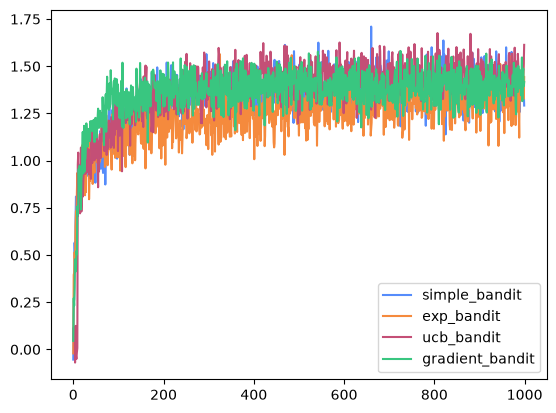

In [7]:
fig, ax = plt.subplots()
for col in df.columns:
    plt.plot(df[col], label=col)
ax.legend()

In [8]:
agent_output['ucb_bandit']['action_log']

array([[[ 3.        , -0.32876395,  0.        ],
        [ 4.        ,  1.44131003,  1.        ],
        [ 9.        ,  1.36262543,  0.        ],
        ...,
        [ 4.        ,  1.26905155,  1.        ],
        [ 4.        ,  1.4265197 ,  1.        ],
        [ 4.        ,  1.58998732,  1.        ]],

       [[ 4.        , -2.66895181,  0.        ],
        [ 2.        ,  0.35062256,  0.        ],
        [ 0.        , -0.37052129,  0.        ],
        ...,
        [ 9.        , -0.67167568,  1.        ],
        [ 9.        ,  0.44029278,  1.        ],
        [ 9.        ,  1.81800602,  1.        ]],

       [[ 3.        , -0.8694209 ,  0.        ],
        [ 8.        ,  0.50015811,  0.        ],
        [ 4.        , -0.43780155,  0.        ],
        ...,
        [ 7.        ,  2.95556787,  1.        ],
        [ 7.        ,  4.73888531,  1.        ],
        [ 7.        ,  1.6016383 ,  1.        ]],

       ...,

       [[ 3.        , -2.05126749,  0.        ],
        [ 8